In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 全局设置（中文+样式）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
file_path = r'stock_data.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8',
    parse_dates=['日期'],
    index_col='日期'
)

df

,开盘价,最高价,最低价,收盘价,成交量(手)
日期,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000
2024-01-03,101.5,103.8,100.2,102.5,18000
2024-01-04,102.8,105.0,101.5,104.2,22000
2024-01-05,104.5,106.2,103.0,105.8,25000
2024-01-08,106.0,107.5,104.8,106.5,20000
2024-01-09,106.8,108.0,105.5,107.2,19000
2024-01-10,107.5,109.0,106.0,108.5,21000
2024-01-11,108.8,110.0,107.5,109.8,23000
2024-01-12,109.5,111.0,108.2,110.5,24000


In [4]:
df.shape

(15, 5)

In [7]:
df.index.min()

Timestamp('2024-01-02 00:00:00')

In [8]:
df.index.max()

Timestamp('2024-01-22 00:00:00')

In [9]:
df.isnull().sum()

开盘价       0
最高价       0
最低价       0
收盘价       0
成交量(手)    0
dtype: int64

In [10]:
df

,开盘价,最高价,最低价,收盘价,成交量(手)
日期,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000
2024-01-03,101.5,103.8,100.2,102.5,18000
2024-01-04,102.8,105.0,101.5,104.2,22000
2024-01-05,104.5,106.2,103.0,105.8,25000
2024-01-08,106.0,107.5,104.8,106.5,20000
2024-01-09,106.8,108.0,105.5,107.2,19000
2024-01-10,107.5,109.0,106.0,108.5,21000
2024-01-11,108.8,110.0,107.5,109.8,23000
2024-01-12,109.5,111.0,108.2,110.5,24000


In [11]:
df['日收益率(%)'] = df['收盘价'].pct_change() * 100
df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%)
日期,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523


In [12]:
df['累计收益率(%)'] = (1 + df['收盘价'].pct_change()).cumprod() * 100 - 100

df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%)
日期,,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585,1.284585
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537,2.964427
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509,4.545455
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626,5.237154
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277,5.928854
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687,7.213439
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157,8.498024
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523,9.189723


In [13]:
df['MA5'] = df['收盘价'].rolling(window=5).mean()
df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%),MA5
日期,,,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN,NaN,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585,1.284585,NaN
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537,2.964427,NaN
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509,4.545455,NaN
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626,5.237154,104.04
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277,5.928854,105.24
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687,7.213439,106.44
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157,8.498024,107.56
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523,9.189723,108.50


In [14]:
df['MA10'] = df['收盘价'].rolling(window=10).mean()
df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%),MA5,MA10
日期,,,,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN,NaN,NaN,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585,1.284585,NaN,NaN
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537,2.964427,NaN,NaN
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509,4.545455,NaN,NaN
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626,5.237154,104.04,NaN
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277,5.928854,105.24,NaN
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687,7.213439,106.44,NaN
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157,8.498024,107.56,NaN
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523,9.189723,108.50,NaN


In [16]:
window = 7
df['BOLL_MID'] = df['收盘价'].rolling(window=window).mean()
df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%),MA5,MA10,BOLL_MID
日期,,,,,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN,NaN,NaN,NaN,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585,1.284585,NaN,NaN,NaN
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537,2.964427,NaN,NaN,NaN
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509,4.545455,NaN,NaN,NaN
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626,5.237154,104.04,NaN,NaN
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277,5.928854,105.24,NaN,NaN
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687,7.213439,106.44,NaN,105.128571
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157,8.498024,107.56,NaN,106.357143
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523,9.189723,108.50,NaN,107.500000


In [17]:
df['BOLL_UPPER'] = df['BOLL_MID'] + 2 * df['收盘价'].rolling(window=window).std()  # 上轨
df['BOLL_LOWER'] = df['BOLL_MID'] - 2 * df['收盘价'].rolling(window=window).std()  # 下轨

In [18]:
df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%),MA5,MA10,BOLL_MID,BOLL_UPPER,BOLL_LOWER
日期,,,,,,,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585,1.284585,NaN,NaN,NaN,NaN,NaN
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537,2.964427,NaN,NaN,NaN,NaN,NaN
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509,4.545455,NaN,NaN,NaN,NaN,NaN
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626,5.237154,104.04,NaN,NaN,NaN,NaN
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277,5.928854,105.24,NaN,NaN,NaN,NaN
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687,7.213439,106.44,NaN,105.128571,110.369073,99.888070
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157,8.498024,107.56,NaN,106.357143,111.324848,101.389438
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523,9.189723,108.50,NaN,107.500000,111.984046,103.015954


In [19]:
df['波动率(%)'] = df['日收益率(%)'].rolling(window=5).std()

In [20]:
df

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%),MA5,MA10,BOLL_MID,BOLL_UPPER,BOLL_LOWER,波动率(%)
日期,,,,,,,,,,,,,
2024-01-02,100.0,102.5,98.8,101.2,15000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03,101.5,103.8,100.2,102.5,18000,1.284585,1.284585,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-04,102.8,105.0,101.5,104.2,22000,1.658537,2.964427,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-05,104.5,106.2,103.0,105.8,25000,1.535509,4.545455,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-08,106.0,107.5,104.8,106.5,20000,0.661626,5.237154,104.04,NaN,NaN,NaN,NaN,NaN
2024-01-09,106.8,108.0,105.5,107.2,19000,0.657277,5.928854,105.24,NaN,NaN,NaN,NaN,0.475966
2024-01-10,107.5,109.0,106.0,108.5,21000,1.212687,7.213439,106.44,NaN,105.128571,110.369073,99.888070,0.472314
2024-01-11,108.8,110.0,107.5,109.8,23000,1.198157,8.498024,107.56,NaN,106.357143,111.324848,101.389438,0.383782
2024-01-12,109.5,111.0,108.2,110.5,24000,0.637523,9.189723,108.50,NaN,107.500000,111.984046,103.015954,0.303223


In [21]:
df_clean = df.dropna()
df_clean

,开盘价,最高价,最低价,收盘价,成交量(手),日收益率(%),累计收益率(%),MA5,MA10,BOLL_MID,BOLL_UPPER,BOLL_LOWER,波动率(%)
日期,,,,,,,,,,,,,
2024-01-15,110.8,112.5,109.5,111.8,26000,1.176471,10.474308,109.56,106.80,108.585714,113.021070,104.150358,0.300713
2024-01-16,112.0,113.8,110.8,112.5,28000,0.626118,11.166008,110.62,107.93,109.542857,114.063708,105.022006,0.309184
2024-01-17,112.8,114.5,111.5,113.2,27000,0.622222,11.857708,111.56,109.00,110.500000,114.848180,106.151820,0.306156
2024-01-18,113.5,115.0,112.0,114.0,29000,0.706714,12.648221,112.40,109.98,111.471429,115.396925,107.545932,0.238748
2024-01-19,114.2,115.8,112.8,113.5,30000,-0.438596,12.154150,113.00,110.75,112.185714,115.329870,109.041559,0.592602
2024-01-22,113.8,114.5,111.5,112.8,28000,-0.616740,11.462451,113.20,111.38,112.614286,114.956446,110.272126,0.649897


In [22]:
total_return = df_clean['累计收益率(%)'].iloc[-1]  # 总累计收益
daily_return_avg = df_clean['日收益率(%)'].mean()  # 日均收益率
volatility_avg = df_clean['波动率(%)'].mean()  # 平均波动率（风险）
sharp_ratio = daily_return_avg / volatility_avg if volatility_avg != 0 else 0  # 夏普比率（风险调整收益）
print("\n3. 核心金融指标：")
print(f"区间总累计收益率：{total_return:.2f}%")
print(f"日均收益率：{daily_return_avg:.2f}%")
print(f"平均波动率（风险）：{volatility_avg:.2f}%")
print(f"夏普比率（风险调整收益）：{sharp_ratio:.2f}")


3. 核心金融指标：
区间总累计收益率：11.46%
日均收益率：0.35%
平均波动率（风险）：0.40%
夏普比率（风险调整收益）：0.87


In [23]:
up_days = len(df_clean[df_clean['日收益率(%)'] > 0])  # 上涨天数
down_days = len(df_clean[df_clean['日收益率(%)'] < 0])  # 下跌天数
flat_days = len(df_clean[df_clean['日收益率(%)'] == 0])  # 平盘天数
print(f"\n涨跌统计：上涨{up_days}天 | 下跌{down_days}天 | 平盘{flat_days}天")


涨跌统计：上涨4天 | 下跌2天 | 平盘0天


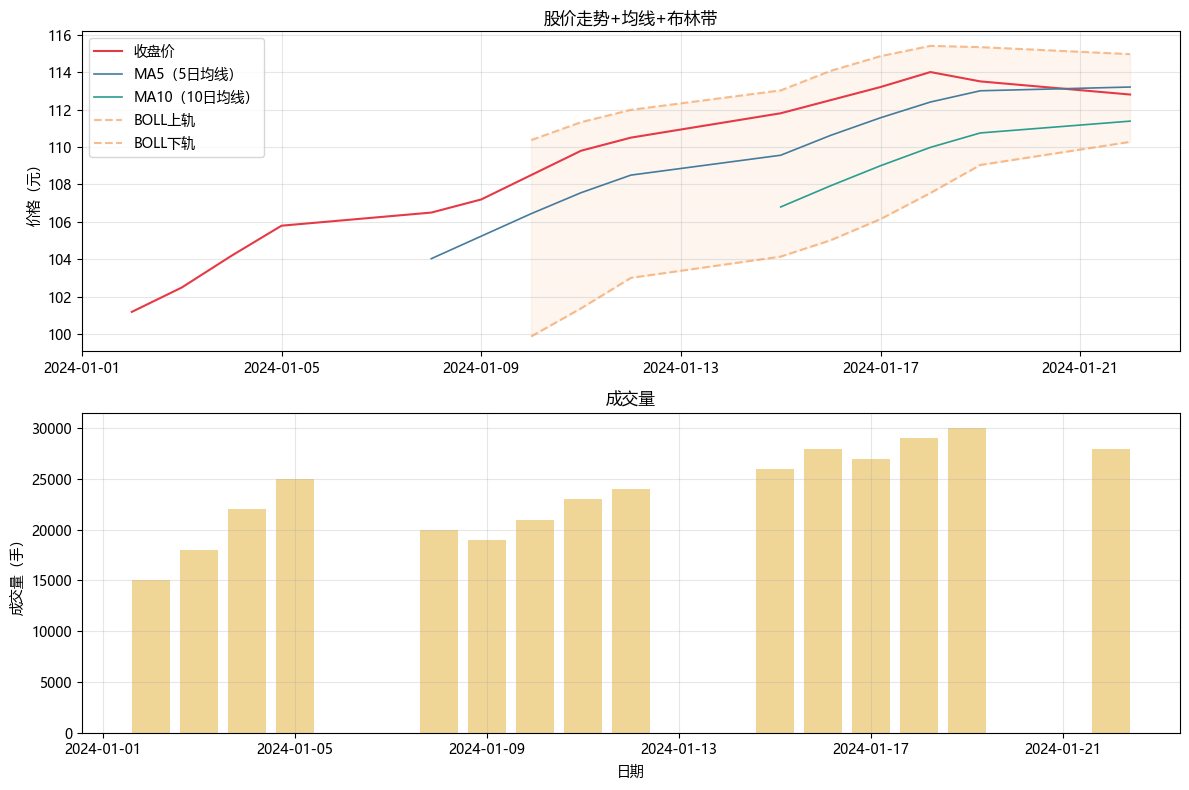

In [24]:
plt.figure(figsize=(12, 8))
# 收盘价+均线
ax1 = plt.subplot(2,1,1)
ax1.plot(df.index, df['收盘价'], label='收盘价', color='#E63946', linewidth=1.5)
ax1.plot(df.index, df['MA5'], label='MA5（5日均线）', color='#457B9D', linewidth=1.2)
ax1.plot(df.index, df['MA10'], label='MA10（10日均线）', color='#2A9D8F', linewidth=1.2)
# 布林带
ax1.plot(df.index, df['BOLL_UPPER'], label='BOLL上轨', color='#F4A261', linestyle='--', alpha=0.7)
ax1.plot(df.index, df['BOLL_LOWER'], label='BOLL下轨', color='#F4A261', linestyle='--', alpha=0.7)
ax1.fill_between(df.index, df['BOLL_LOWER'], df['BOLL_UPPER'], color='#F4A261', alpha=0.1)
ax1.set_title('股价走势+均线+布林带')
ax1.set_ylabel('价格（元）')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)# 成交量子图
ax2 = plt.subplot(2,1,2)
ax2.bar(df.index, df['成交量(手)'], color='#E9C46A', alpha=0.7)
ax2.set_title('成交量')
ax2.set_xlabel('日期')
ax2.set_ylabel('成交量（手）')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

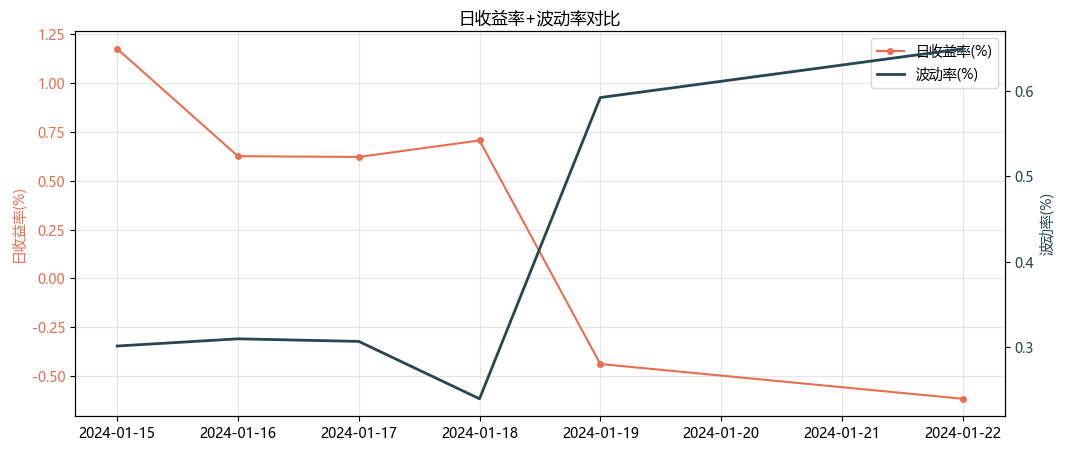

In [25]:
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1,1,1)
# 日收益率
ax1.plot(df_clean.index, df_clean['日收益率(%)'], label='日收益率(%)', color='#E76F51', marker='o', markersize=4)
ax1.set_ylabel('日收益率(%)', color='#E76F51')
ax1.tick_params(axis='y', labelcolor='#E76F51')
# 波动率（双Y轴）
ax2 = ax1.twinx()
ax2.plot(df_clean.index, df_clean['波动率(%)'], label='波动率(%)', color='#264653', linewidth=2)
ax2.set_ylabel('波动率(%)', color='#264653')
ax2.tick_params(axis='y', labelcolor='#264653')
# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
ax1.set_title('日收益率+波动率对比')
ax1.grid(alpha=0.3)
plt.show()

In [26]:
df_clean.to_excel('金融时间序列分析结果.xlsx')
print("\n5. 分析结果已导出为Excel文件！")


5. 分析结果已导出为Excel文件！
